In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv(r"ev_market_2026.csv")

In [9]:
df

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,BMW,i3,2023,Long Range,122665.71,102.1,360.0,92.0,4.21,190.0,...,Hatchback,38.3,1500.0,5,2,Germany,Luxury,66187,3.78,7
1996,Toyota,bZ4X,2024,Performance,66816.55,110.6,367.0,236.3,4.25,181.0,...,Hatchback,23.1,1863.0,4,0,Japan,Premium,11062,3.79,4
1997,Tesla,Model 3,2025,Long Range,49281.26,90.6,325.0,325.6,5.55,167.0,...,Truck,74.6,2920.0,3,3,US,Mid-range,224804,4.10,6
1998,Tesla,Model X,2026,Premium,139665.73,70.7,248.0,330.7,5.07,175.0,...,Coupe,34.8,1500.0,3,2,US,Luxury,165373,3.66,4


In [14]:
df.columns

Index(['brand', 'model', 'year', 'variant', 'price_usd',
       'battery_capacity_kwh', 'range_miles', 'charging_speed_kw',
       'acceleration_0_60_mph', 'top_speed_mph', 'horsepower', 'torque_nm',
       'drive_type', 'seating_capacity', 'body_type', 'cargo_volume_cubic_ft',
       'weight_kg', 'safety_rating', 'autopilot_level', 'country_of_origin',
       'market_segment', 'annual_sales_units', 'customer_rating',
       'warranty_years'],
      dtype='object')

**Ev Sales by brand**

**Which brands dominate the EV market?**

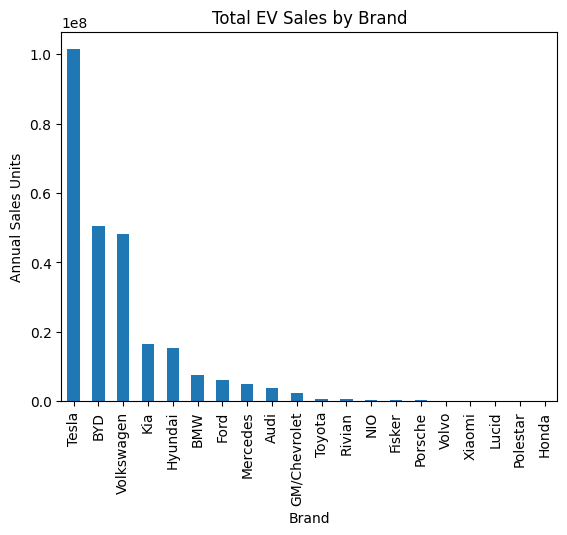

In [21]:
brand_sales = df.groupby("brand")["annual_sales_units"].sum().sort_values(ascending=False)
ax = brand_sales.plot(kind = 'bar')

plt.title("Total EV Sales by Brand")
plt.xlabel("Brand")
plt.ylabel("Annual Sales Units")

#for i, v in enumerate(brand_sales):
    #ax.text(i, v, f'{v:,.0f}', ha='center',va='bottom')

plt.show()

**Tesla has the larget market share followed by BYD and volkswagen**

**Top 3 brands contribute for more than 75% of the sales**

Text(0, 0.5, 'Annual Sales Units')

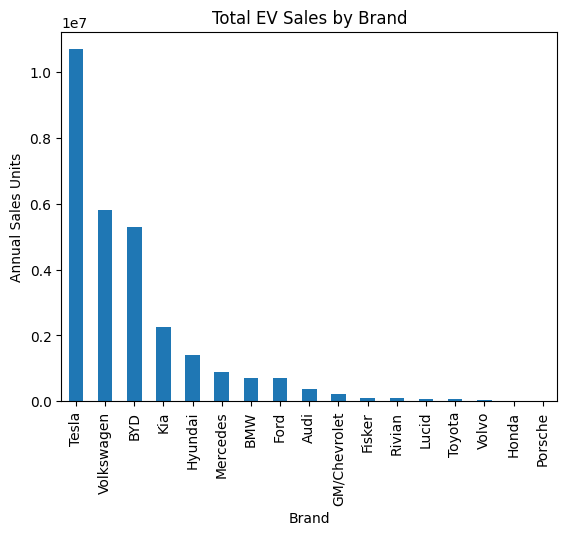

In [23]:
brand_sales = df[df['year'] == 2026].groupby("brand")["annual_sales_units"].sum().sort_values(ascending=False)
ax = brand_sales.plot(kind = 'bar')

plt.title("Total EV Sales by Brand")
plt.xlabel("Brand")
plt.ylabel("Annual Sales Units")

**Sales by Country**

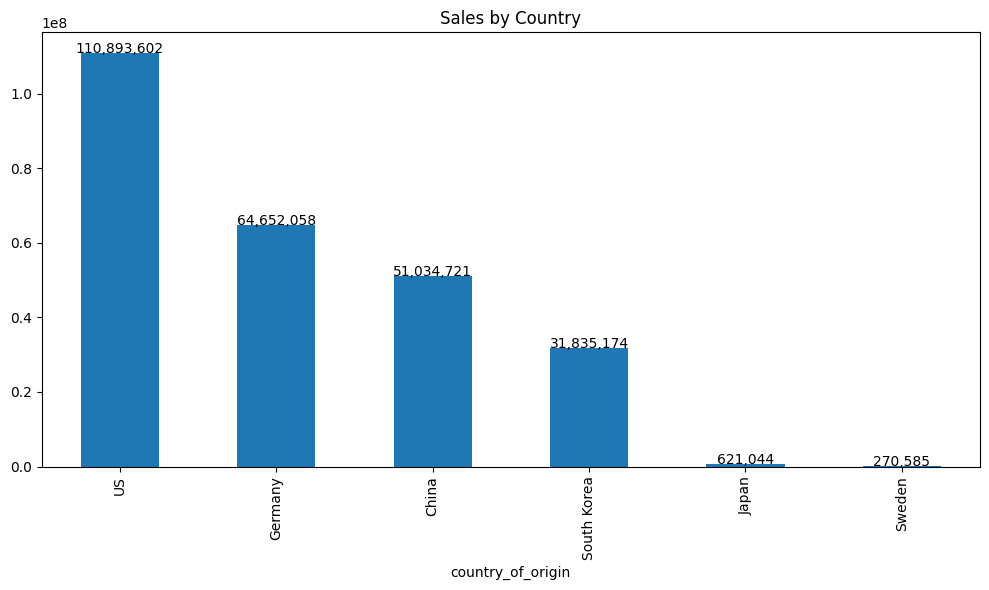

In [24]:
country_sales = (df.groupby("country_of_origin")["annual_sales_units"].sum().sort_values(ascending=False))

ax = country_sales.plot(kind="bar",figsize=(10,6),title="Sales by Country")
for i,v in enumerate(country_sales):
    ax.text(i,v,f'{v:,.0f}',ha='center')

plt.tight_layout()
plt.show()

**US is the largest EV market**

**Market Share Pie Chart**

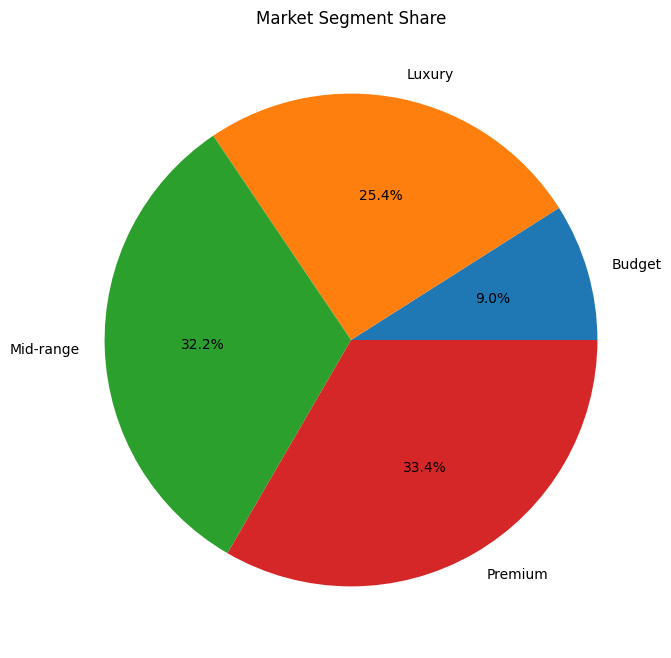

In [25]:
segment_sales = (df.groupby("market_segment")["annual_sales_units"].sum())

plt.figure(figsize=(8,8))

plt.pie(segment_sales,labels=segment_sales.index,autopct='%1.1f%%')

plt.title("Market Segment Share")
plt.show()

- **Premium and Mid-range segments account for the largest share of EV sales.**
- **Countries with established EV infrastructure and strong manufacturing presence dominate overall sales.**
- **The distribution highlights the global shift toward electrification, though adoption remains uneven across regions.**
                                         

**Average Price by Brand**

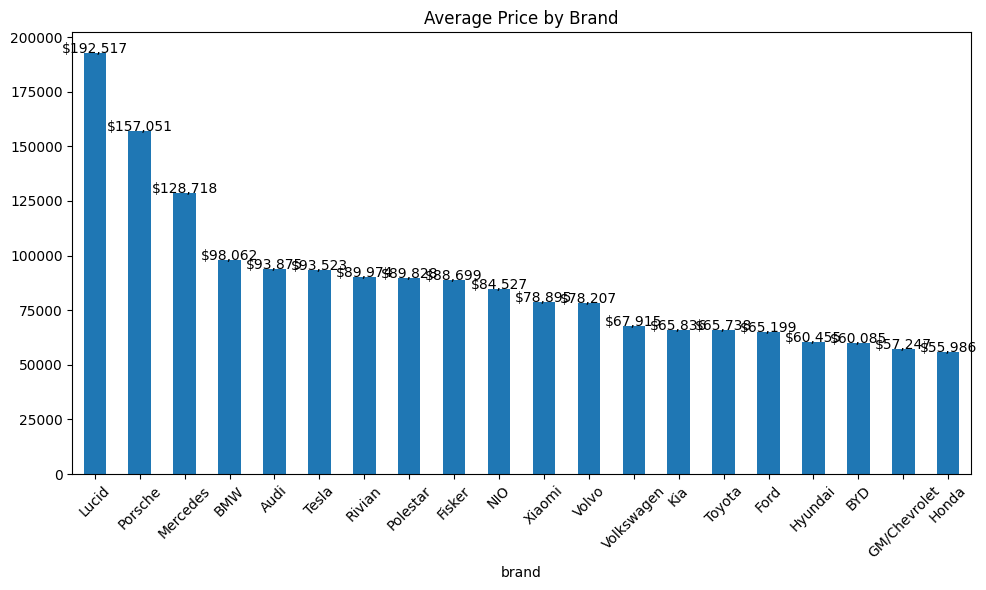

In [26]:
avg_price = (df.groupby("brand")["price_usd"].mean().sort_values(ascending=False))

ax = avg_price.plot(kind="bar",figsize=(10,6),title="Average Price by Brand")

for i,v in enumerate(avg_price):
    ax.text(i,v,f'${v:,.0f}',ha='center')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Luxury manufacturers command substantially higher average prices than mass-market brands.**

**Customer Rating by Brand**

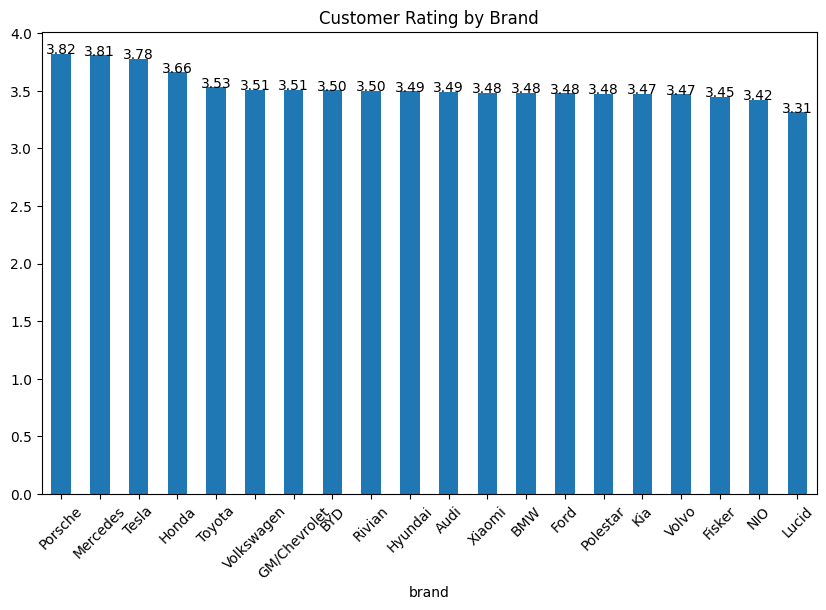

In [28]:
brand_rating = (df.groupby("brand")["customer_rating"].mean().sort_values(ascending=False))

ax = brand_rating.plot(kind="bar",figsize=(10,6),title="Customer Rating by Brand")

for i,v in enumerate(brand_rating):
    ax.text(i,v,f'{v:.2f}',ha='center')

plt.xticks(rotation=45)
plt.show()

- **Customer satisfaction varies across manufacturers despite similar vehicle specifications.**
- **Several mainstream brands achieve ratings comparable to premium competitors.**

**Safety Rating by Brand**

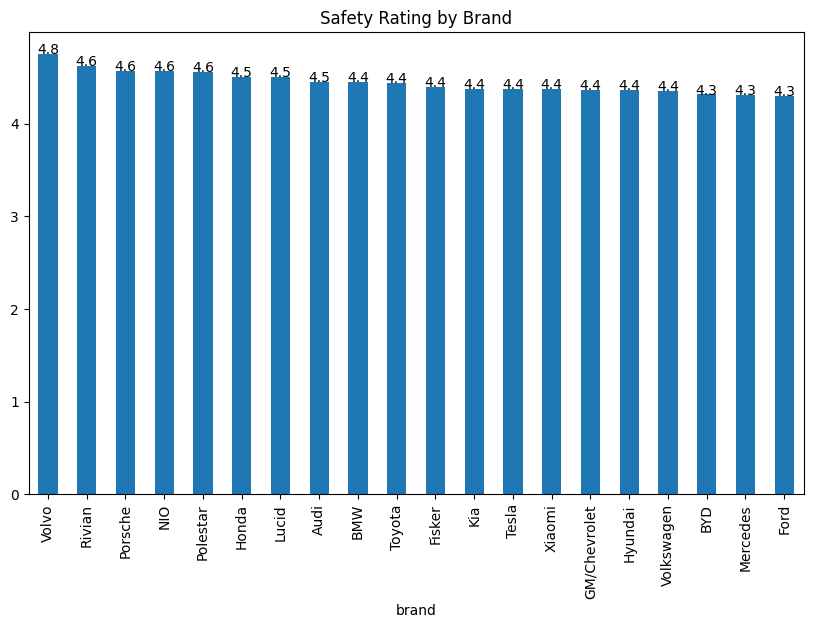

In [29]:
safety = (df.groupby("brand")["safety_rating"].mean().sort_values(ascending=False))

ax = safety.plot(kind="bar",figsize=(10,6),title="Safety Rating by Brand")

for i,v in enumerate(safety):
    ax.text(i,v,f'{v:.1f}',ha='center')

plt.show()

- **Most EV brands maintain strong safety standards, with only minor differences between manufacturers.**

**Range vs Sales**

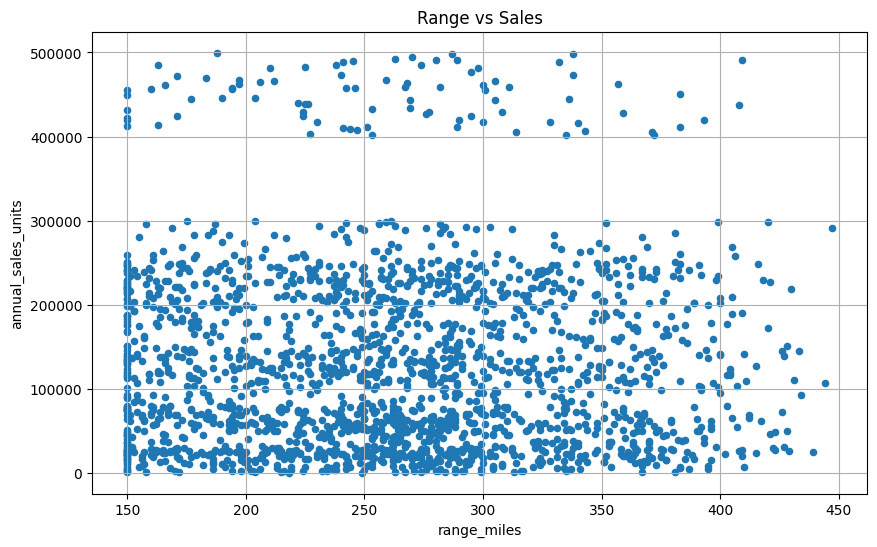

In [30]:
ax = df.plot(kind="scatter", x="range_miles", y="annual_sales_units", figsize=(10,6), title="Range vs Sales")

plt.grid(True)
plt.show()

- **Correlation shows almost no relationship with sales.**
- **Driving range alone does not appear to be a major determinant of sales volume.**

**Battery Capacity vs Range**

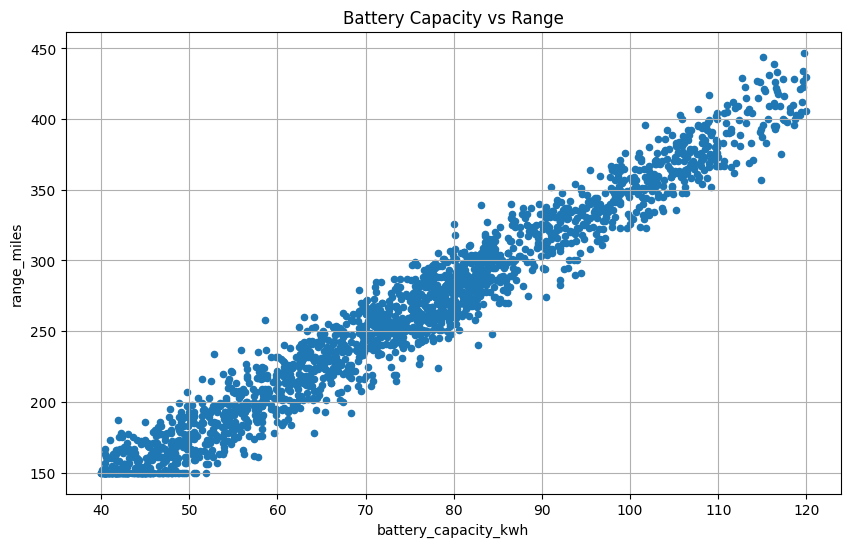

In [31]:
ax = df.plot(kind="scatter", x="battery_capacity_kwh", y="range_miles", figsize=(10,6), title="Battery Capacity vs Range")

plt.grid(True)
plt.show()

- **Battery capacity exhibits an extremely strong positive relationship with driving range.**
- **Vehicles equipped with larger battery packs consistently achieve greater range.**

**Charging Speed vs Sales**

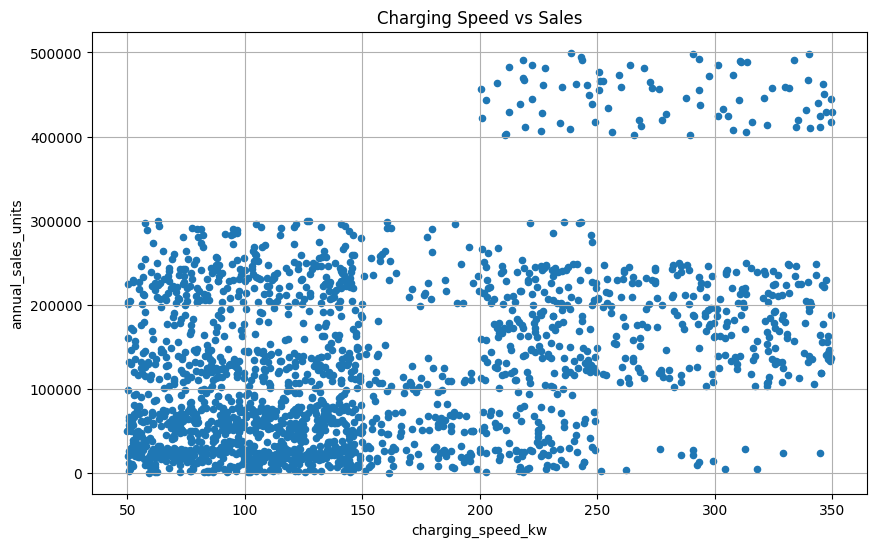

In [32]:
ax = df.plot(kind="scatter", x="charging_speed_kw", y="annual_sales_units", figsize=(10,6), title="Charging Speed vs Sales")

plt.grid(True)
plt.show()

- **Faster charging capability does not appear to directly drive higher sales volumes.**
- **Consumers may prioritize brand reputation, range, and pricing over charging speed.**

**Price vs Customer Rating**

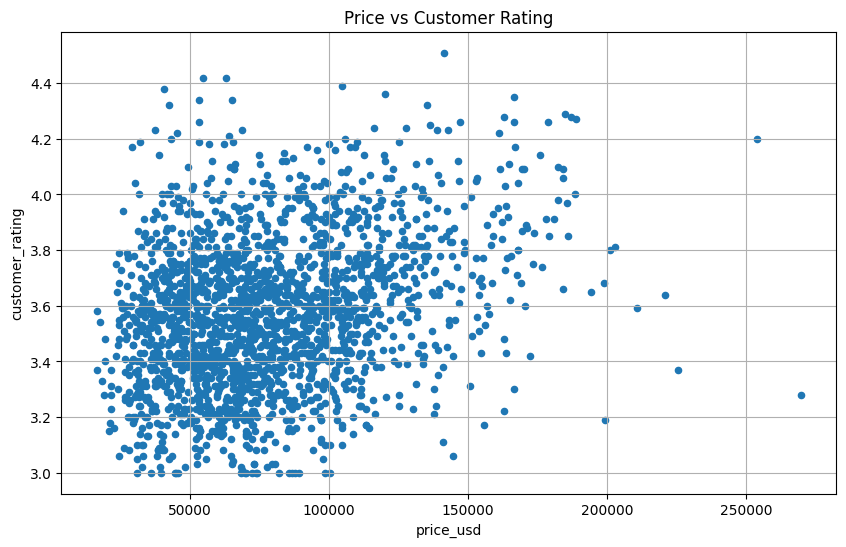

In [33]:
ax = df.plot(kind="scatter", x="price_usd", y="customer_rating", figsize=(10,6), title="Price vs Customer Rating")

plt.grid(True)
plt.show()

- **More expensive EVs tend to receive slightly better customer ratings.**
- **The relationship is relatively weak, suggesting affordability and satisfaction are not mutually exclusive.**

**Price Distribution**

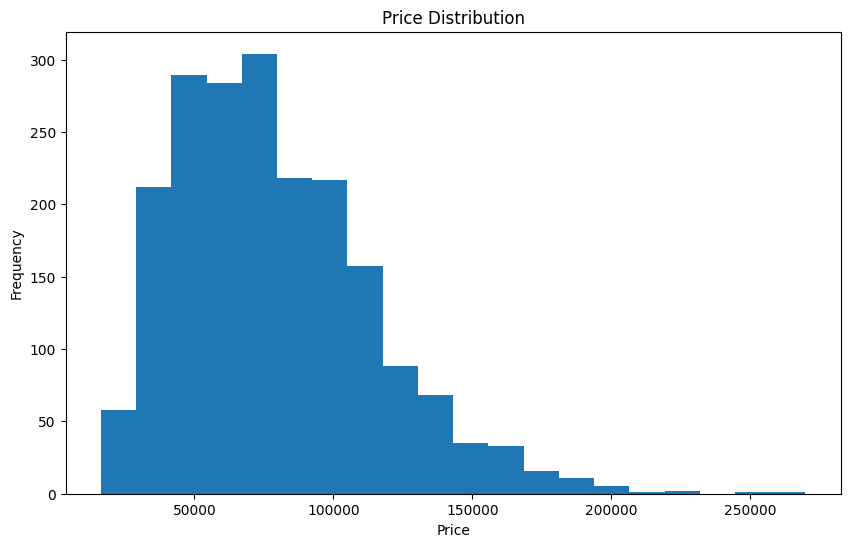

In [36]:
ax = df["price_usd"].plot(kind="hist", bins=20, figsize=(10,6), title="Price Distribution")

plt.xlabel("Price")
plt.show()

- **Most vehicles are concentrated in the mid-price segment.**
- **The distribution indicates a balance between affordable and premium EV options.**

**Range Distribution**

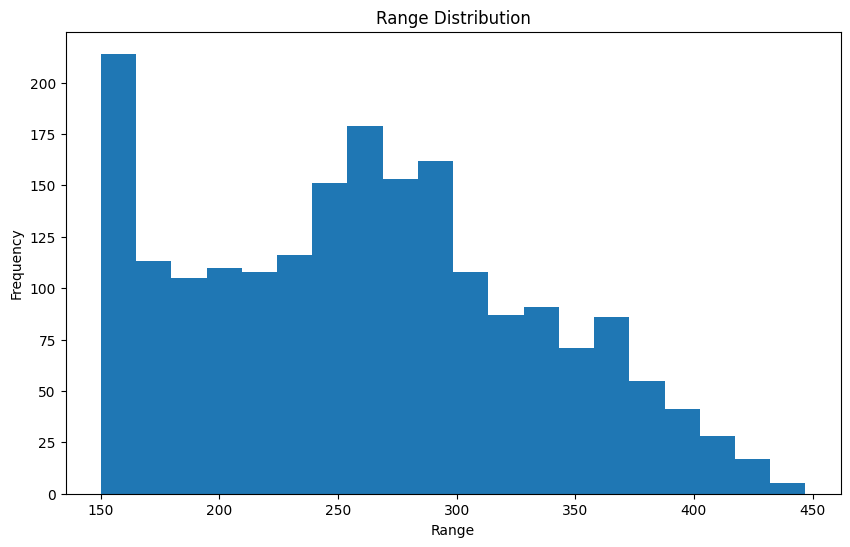

In [37]:
ax = df["range_miles"].plot(kind="hist", bins=20, figsize=(10,6), title="Range Distribution")

plt.xlabel("Range")
plt.show()

- **Most EVs cluster around a moderate driving range suitable for daily commuting.**
- **Extremely low-range and extremely high-range vehicles represent a smaller share of the market.**

**Average Range by Body Type**

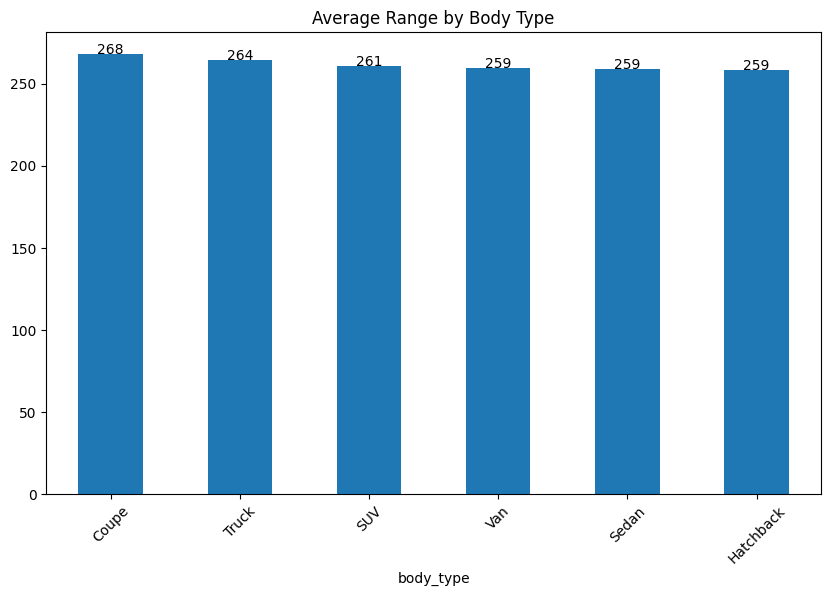

In [38]:
body_range = (df.groupby("body_type")["range_miles"].mean().sort_values(ascending=False))

ax = body_range.plot(kind="bar", figsize=(10,6), title="Average Range by Body Type")

for i,v in enumerate(body_range):
    ax.text(i,v,f'{v:.0f}',ha='center')

plt.xticks(rotation=45)
plt.show()

- **Certain body types achieve greater average range due to larger battery capacities and improved efficiency.**

**Sales by Body Type**

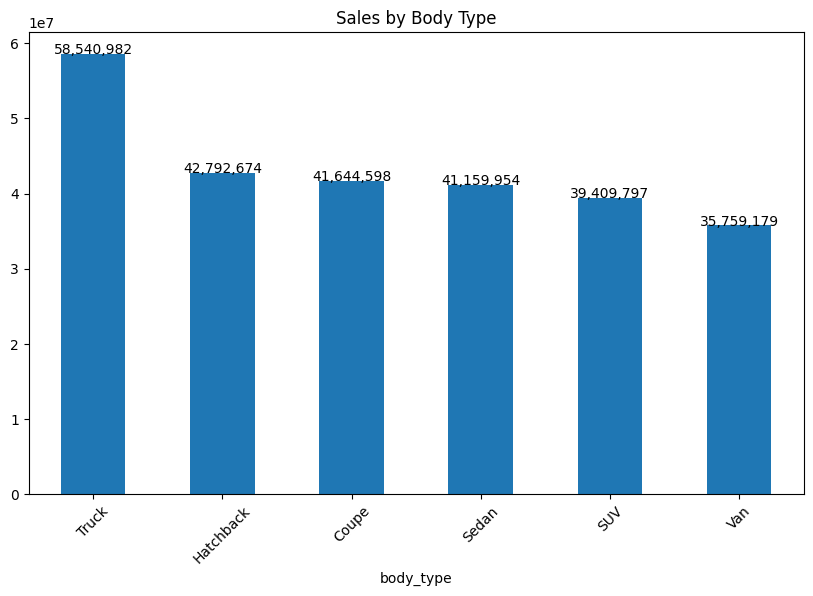

In [39]:
body_sales = (df.groupby("body_type")["annual_sales_units"].sum().sort_values(ascending=False))

ax = body_sales.plot(kind="bar", figsize=(10,6), title="Sales by Body Type")

for i,v in enumerate(body_sales):
    ax.text(i,v,f'{v:,.0f}',ha='center')

plt.xticks(rotation=45)
plt.show()

- **Consumer demand is concentrated among a few popular body styles.**
- **Body style remains an important factor influencing purchasing decisions.**

**Luxury vs Economy Comparison**

In [40]:
segment_summary = (df.groupby("market_segment")
      .agg(
          avg_price=("price_usd","mean"),
          avg_range=("range_miles","mean"),
          avg_rating=("customer_rating","mean"),
          total_sales=("annual_sales_units","sum")
      )
)

print(segment_summary)

                    avg_price   avg_range  avg_rating  total_sales
market_segment                                                    
Budget           29320.750861  236.086093    3.454967     23353407
Luxury          127339.967960  275.292929    3.698949     65966088
Mid-range        50688.845779  255.149533    3.530607     83479890
Premium          81102.328357  263.941011    3.546011     86507799


- **Premium vehicles generated the highest total sales, followed closely by Mid-range vehicles.**
- **Budget EVs have the lowest average selling price and contribute the least total sales.**
- **Luxury vehicles command the highest prices but do not dominate sales volume.**
- **The strongest market demand is concentrated in the Premium and Mid-range categories.**

**Top 10 Best Selling Models**

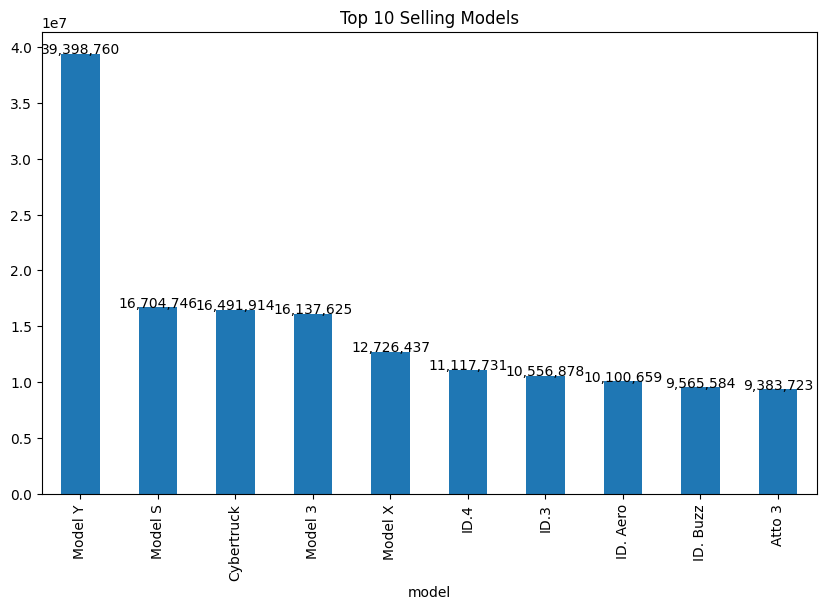

In [41]:
top_models = (df.groupby("model")["annual_sales_units"].sum().sort_values(ascending=False).head(10))

ax = top_models.plot(kind="bar", figsize=(10,6), title="Top 10 Selling Models")

for i,v in enumerate(top_models):
    ax.text(i,v,f'{v:,.0f}',ha='center')

plt.show()

- **A small number of models account for a substantial share of total EV sales.**
- **Market leaders benefit from strong brand recognition and broad consumer acceptance.**

**Value-for-Money Score**

In [42]:
df["value_score"] = (df["range_miles"] + df["horsepower"]) / df["price_usd"]

top_value = (df[["brand", "model", "price_usd", "range_miles", "horsepower", "value_score"]].sort_values(by="value_score", ascending=False))

print(top_value.head(10))

      brand    model  price_usd  range_miles  horsepower  value_score
1055    BYD  Seagull   16613.01        237.0       202.0     0.026425
852     BYD      Qin   17777.32        280.0       175.0     0.025594
158     BYD  Seagull   19470.99        291.0       204.0     0.025422
1533    BYD      Qin   27057.77        385.0       295.0     0.025131
830     BYD   Atto 3   31933.47        430.0       363.0     0.024833
1775    BYD   Atto 3   26097.55        367.0       270.0     0.024408
124     BYD      Qin   21712.40        307.0       190.0     0.022890
744     BYD  Dolphin   24263.38        313.0       236.0     0.022627
531   Honda    e:Ny1   51309.25        410.0       742.0     0.022452
1308    BYD      Qin   24219.14        265.0       267.0     0.021966


- **BYD dominates the value-for-money ranking, indicating strong specifications at competitive prices.**
- **High prices do not necessarily guarantee better value for consumers.**
- **BYD demonstrates a strong balance between performance, range, and affordability.**

**Correlation Analysis**

In [44]:
numeric_cols = [
    "price_usd",
    "battery_capacity_kwh",
    "range_miles",
    "charging_speed_kw",
    "horsepower",
    "torque_nm",
    "weight_kg",
    "annual_sales_units",
    "customer_rating"
]

corr = df[numeric_cols].corr()

print(corr)

                      price_usd  battery_capacity_kwh  range_miles  \
price_usd              1.000000              0.163565     0.156174   
battery_capacity_kwh   0.163565              1.000000     0.977859   
range_miles            0.156174              0.977859     1.000000   
charging_speed_kw      0.302888              0.155309     0.148906   
horsepower             0.764724              0.199032     0.192405   
torque_nm              0.759726              0.197377     0.190323   
weight_kg              0.006261              0.034911     0.036884   
annual_sales_units    -0.030502             -0.006791    -0.012127   
customer_rating        0.298409              0.658008     0.668137   

                      charging_speed_kw  horsepower  torque_nm  weight_kg  \
price_usd                      0.302888    0.764724   0.759726   0.006261   
battery_capacity_kwh           0.155309    0.199032   0.197377   0.034911   
range_miles                    0.148906    0.192405   0.190323   0.0

- **Battery capacity and driving range exhibit the strongest relationship in the dataset.**
- **Customer ratings increase with greater range and battery capacity, suggesting consumers value practicality.**
- **Higher-priced vehicles generally offer more horsepower and torque.**
- **Technical specifications have little direct impact on sales volume, indicating that non-technical factors such as brand image and marketing play a significant role in purchasing decisions.**